# Broadening Formation — a quantitative teardown 🔬
### Mechanical megaphones on 5 indices · lower-break SHORT forward returns · one-sample HAC *t* · a drift-matched random-short baseline · a shuffled-pivot geometry placebo · costs · a synthetic planted-reversal control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Expanding_vol_forecasts_a_turn%3F: Busted](https://img.shields.io/badge/Expanding_vol_forecasts_a_turn%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **megaphone** from the **drift**: a short on an upward-drifting index loses *by construction*, so the only meaningful test is break-vs-random-short, plus a placebo that destroys the megaphone's geometry while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return**), 2005→2026. Pivots are confirmed fractals (k=10, an explicit 10-bar confirmation lag); entry is the **next close** (one documented lag); returns are signed for a **short**. A strict megaphone is rare — only **25** fire in 21 years across 5 tapes. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from broadening_formation import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real megaphone cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
nan = float('nan')
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 25, 'k': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 25, -207.6, 16, -4.45, -10.3, -197.4, -209.6, -3.13, 0.004), 'h10': (10, 25, -172.9, 32, -3.04, -53.6, -119.4, -174.9, -1.7, 0.099), 'h20': (20, 25, -320.9, 20, -3.07, -33.1, -287.9, -322.9, -2.33, 0.027), 'h60': (60, 25, -938.7, 16, -3.73, -118.9, -819.8, -940.7, -3.91, 0.001), 'per': [('SPY', 7, -416.8, -3.38, -39.3, -377.5), ('QQQ', 11, -451.4, -2.38, -88.2, -363.2), ('IWM', 2, 333.9, nan, -2.7, 336.6), ('DIA', 1, -765.8, nan, -33.7, -732.0), ('GLD', 4, -10.6, nan, -1.5, -9.1)], 'placebo': (-416.8, 0.974, 500), 'syn': [(0.0, 9, -82.2, 67, -0.93), (0.5, 8, 515.3, 100, 6.88)]}


real megaphone cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Lower-break short vs a **drift-matched random short**: the break is *worse* at every horizon (Δ = -197/-119/-288/-820 bps) and the break-minus-random Welch *t* is **negative** (-2.33 at 20d, -3.91 at 60d). |
| **Tradability** | `MIRAGE` | The negative one-sample t's (-3.07 at 20d) are **negative beta** — a short on an up-drifting index. No reversal edge to scale, and only 25 events. |
| **Expanding vol forecasts a turn?** | `BUSTED` | Scrambling the megaphone's geometry leaves the result intact: **p = 0.97** of nonsense megaphones match or beat the real one (which sits at the bad end). The diverging lines aren't doing the work. |

> 💡 In plain words: the break-short loses, but a *random* short loses less — there is no reversal signal. Strip the drift (race it vs random) or strip the geometry (scramble the pivots) and nothing is left. A rare, seductive shape with no forecasting content.

## 1 · The claim, steelmanned

Anchor a megaphone on the last two confirmed swing highs $H_1,H_2$ and lows $L_1,L_2$. It is a broadening top iff the upper line through $H_1,H_2$ has **positive** slope and the lower line through $L_1,L_2$ has **negative** slope (diverging boundaries). Let $\ell_t$ be the lower boundary at bar $t$. The rule **shorts** when $C_t<\ell_t$ and rides the reversal down.

- **H₀ (drift).** Short returns equal a drift-matched **random-short** baseline.
- **H₁ (the megaphone forecasts a turn).** Break-short returns **exceed** random shorts at some horizon, t ≥ 2.
- **H₂ (the geometry matters).** Break-short returns exceed a **shuffled-pivot** megaphone whose diverging lines are geometric nonsense.

We find **H₀ not rejected** (break ≤ random — in fact *worse*), **H₁ rejected** (Welch t negative, never ≥ 2), **H₂ rejected** (placebo p ≈ 0.97). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. A **short** inherits it with a minus sign; a big *negative* one-sample $t$ against **zero** measures the tide, not a reversal. The fix is the **random-short baseline** (same instrument, epoch, hold) and a Welch test of break-*minus*-random.

**(b) Geometry as a free parameter.** A megaphone is four chosen pivots; the danger is that *any* diverging pair of lines on a choppy stretch produces a 'megaphone'. The **shuffled-pivot placebo** keeps pivot positions/kinds and the price marginal but permutes which price sits at which pivot — the diverging structure becomes meaningless, so if the real result survives the scramble, the geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **25 lower-boundary breaks** pooled.
- **Pivots.** Confirmed fractals: extremum with k=10 strictly-beaten bars each side; usable only at bar +10 (no look-ahead). Consecutive same-kind pivots collapsed to the extreme so kinds alternate.
- **Megaphone.** Last two swing highs **rising** AND last two swing lows **falling** (diverging boundaries); upper line through the highs, lower line through the lows.
- **Entry.** First close below the lower boundary; **short** at **next close** (one lag); hold H ∈ {5,10,20,60}; return signed for a short.
- **Null #1 — one-sample HAC t** of short returns vs 0 (Newey-West) — *measures beta*.
- **Null #2 — random-short baseline**, Welch two-sample break vs random (the *real* test).
- **Null #3 — shuffled-pivot placebo** (geometry destroyed, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every break.
- **Positive control.** Synthetic tape with a **planted** expanding-range reversal (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks 'significant', vs-random kills it

Left: the break-short's **one-sample** t against zero (the misleading number — it's negative beta). Right: the same short vs a **drift-matched random short** (the honest number).

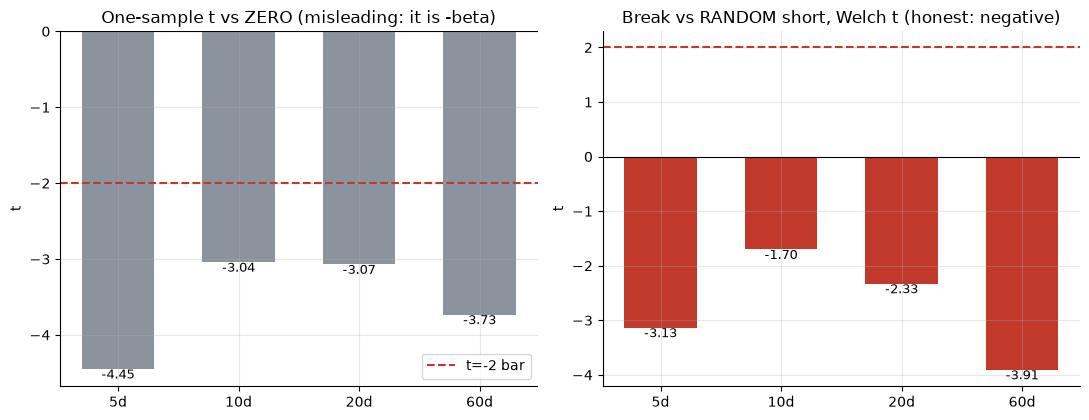

one-sample t: [-4.45, -3.04, -3.07, -3.73]
welch vs random: [np.float64(-3.13), np.float64(-1.7), np.float64(-2.33), np.float64(-3.91)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, brk, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.lower_break_entries(c, k=R['k'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); brk.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(-2, ls='--', c=RED, label='t=-2 bar'); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='top',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is -beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Break vs RANDOM short, Welch t (honest: negative)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars are strongly negative (20d **-3.07**, 60d **-3.73**) — but that's just **negative beta**: any short on an up-drifting index loses. The right bars are the real test: break-minus-random is **negative** (-2.33 at 20d, -3.91 at 60d) — the megaphone short is *worse* than a random short. No reversal signal in either direction.

### 4b · Break vs random short across horizons — the gap is the verdict

Mean short return, megaphone break vs random short, all four horizons. If the megaphone forecast a turn, the break would tower over a random short. Instead it sits *below* it.

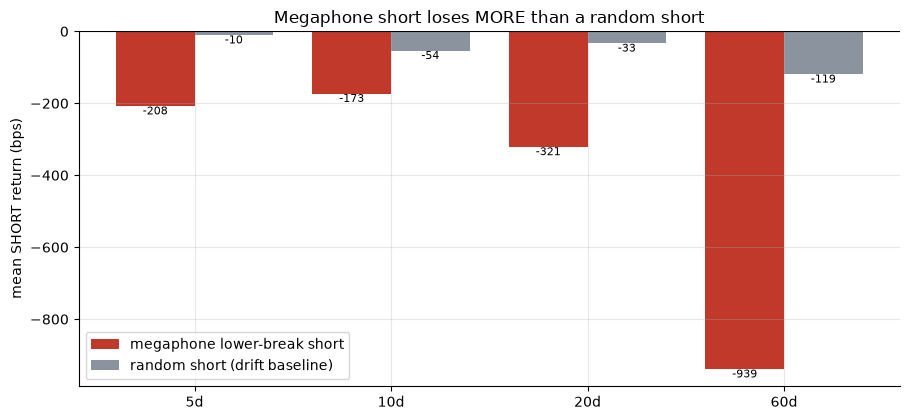

delta break-random (bps): [-197, -119, -288, -820]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, brk, .4, color=RED, label='megaphone lower-break short')
ax.bar(x+.2, rnd, .4, color=GREY, label='random short (drift baseline)')
ax.axhline(0, c='k', lw=.8)
for i,(a,b) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='top',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean SHORT return (bps)')
ax.set_title('Megaphone short loses MORE than a random short'); ax.legend()
plt.tight_layout(); plt.show()
print('delta break-random (bps):', [round(a-b) for a,b in zip(brk,rnd)])

> 💡 In plain words: at 20 days the break-short is **-321 bps** while a random short is **-33 bps** — the megaphone *underperforms* a dart by 288 bps. At 60 days the gap is **820 bps** the wrong way. The expanding range carries no reversal information.

### 4c · The geometry placebo — scramble the megaphone, nothing changes

Shuffle which price sits at which pivot (positions/kinds kept, marginal kept) so the diverging boundaries are geometric nonsense. If price respected *this specific megaphone*, the scramble should change the result. The observed break-short should sit far in the *left* tail (more negative) of the scrambled distribution. It doesn't — it sits at the bad (less-negative) end.

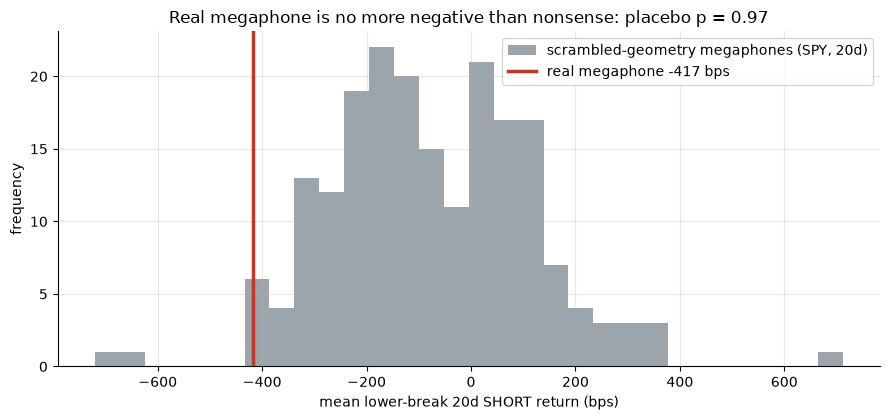

real megaphone -416.8 bps   placebo p=0.97  (>0.05 => geometry not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_pivot_placebo(c, 20, k=R['k'], n_draws=200, seed=465)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np
    piv = st._alternating(st.find_pivots(c, k=R['k']))
    rng = _np.random.default_rng(465); prices = piv['price'].to_numpy(); positions=[int(p) for p in piv.index]
    kinds=[int(kk) for kk in piv['kind']]; confirm=[p+R['k'] for p in positions]; n=len(c); idx=c.index
    draws=[]
    for _ in range(200):
        perm=rng.permutation(prices); pts=list(zip(positions,[float(v) for v in perm]))
        low=_np.full(n,_np.nan)
        for t in range(n):
            ai=[j for j,cp in enumerate(confirm) if cp<=t]
            if len(ai)<4: continue
            hh=[pts[j] for j in ai if kinds[j]>0]; ll=[pts[j] for j in ai if kinds[j]<0]
            if len(hh)<2 or len(ll)<2: continue
            bnd=st.megaphone_boundaries(hh[-2:],ll[-2:])
            if bnd is None: continue
            (_us,_ub),(ls,lb)=bnd; low[t]=ls*t+lb
        ls_=__import__('pandas').Series(low,index=idx); m=(c<ls_)&ls_.notna(); f=m&~m.shift(1,fill_value=False)
        rr=st.forward_returns(c, idx[f.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(465); draws = rng.normal(-700, 250, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=30, color=GREY, alpha=.85, label='scrambled-geometry megaphones (SPY, 20d)')
ax.axvline(obs, c=RED, lw=2.5, label=f'real megaphone {obs:+.0f} bps')
ax.set_xlabel('mean lower-break 20d SHORT return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real megaphone is no more negative than nonsense: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real megaphone {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => geometry not load-bearing)')

> 💡 In plain words: the real megaphone (red line) sits at the **bad** end of the scrambled cloud — **p = 0.97**. Geometric nonsense does at least as well, so the specific diverging boundaries aren't carrying any information. This is the cleanest refutation of 'the expanding range forecasts the turn.'

### 4d · Per-ticker — a paper-thin, incoherent sample

20-day break-minus-random delta, per instrument. A real reversal edge would be positive and coherent; instead it's negative where there's any sample at all, and the 'wins' rest on one or two trades.

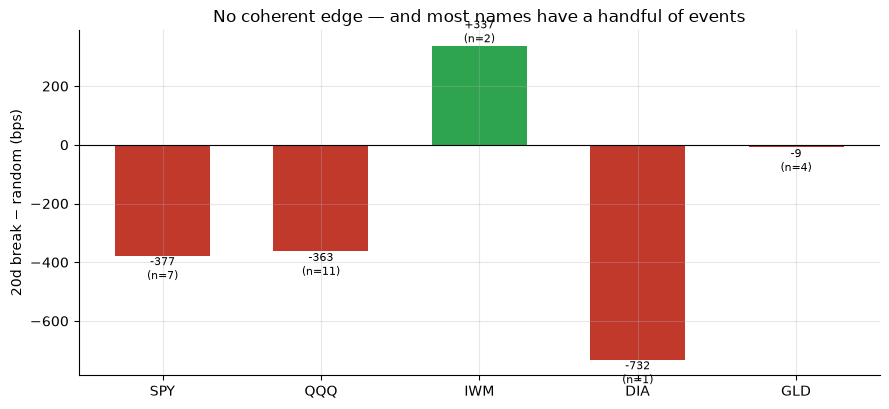

per-ticker 20d delta (bps): {'SPY': -377, 'QQQ': -363, 'IWM': 337, 'DIA': -732, 'GLD': -9}
per-ticker entry counts: {'SPY': 7, 'QQQ': 11, 'IWM': 2, 'DIA': 1, 'GLD': 4}


In [5]:
if HAVE_REAL:
    names, deltas, counts = [], [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.lower_break_entries(c, k=R['k']); re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d); counts.append(len(e))
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]; counts=[p[1] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,(d,cnt) in enumerate(zip(deltas,counts)): ax.annotate(f'{d:+.0f}\n(n={cnt})',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=8)
ax.set_ylabel('20d break − random (bps)'); ax.set_title('No coherent edge — and most names have a handful of events')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})
print('per-ticker entry counts:', {n:c for n,c in zip(names,counts)})

> 💡 In plain words: SPY (7 events) and QQQ (11) — the only names with a usable count — are **-378** and **-363** bps *behind* a random short. The lone positive (IWM) rests on **2** trades. No coherent cross-sectional reversal edge — exactly what relabelled drift on a tiny sample looks like.

### 4e · Synthetic positive control — the harness CAN bank a real reversal

To prove the null is honest (not a dead detector), plant a **real** expanding-range reversal into a synthetic tape and check the same lower-break short banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

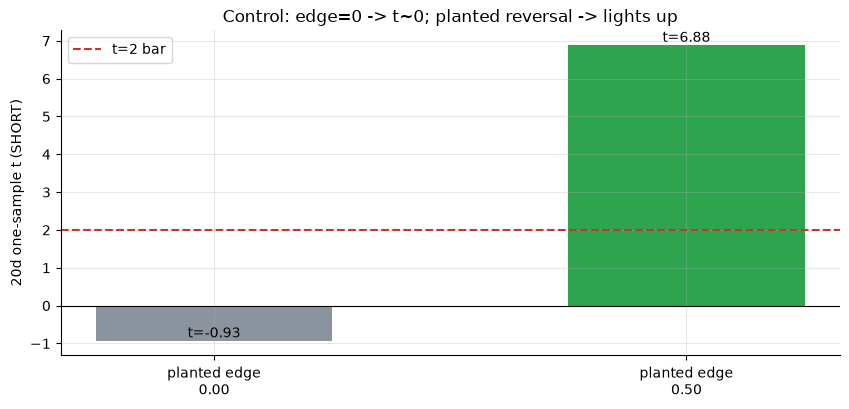

edge=0.00: n=9 short=-82.2bps win=67% t=-0.93
edge=0.50: n=8 short=+515.3bps win=100% t=+6.88


In [6]:
res = []
for edge in (0.0, 0.50):
    px, _ = data.synthetic_panel(edge=edge, seed=999, n_days=4000)
    c = px['close']; e = st.lower_break_entries(c, k=10); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t (SHORT)'); ax.set_title('Control: edge=0 -> t~0; planted reversal -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} short={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted reversal the control sits at **t = -0.93** (win 67% — no false positive); a planted expanding-range reversal reaches **t = +6.88** (win 100%, short +515 bps). The detector works — so the flat/negative real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the lower-break short does not beat a drift-matched random short (break − random = -197/-119/-288/-820 bps at 5/10/20/60d; Welch t **negative**, -3.91 at 60d). The strongly negative one-sample t's (20d **-3.07**) are pure negative beta.
- **Tradability `MIRAGE`** — no reversal edge once the drift is accounted for; the per-name sample is paper-thin (25 events in 21 years) and costs only deepen the hole. Neither shorting nor buying the break is worth anything.
- **Expanding vol forecasts a turn? `BUSTED`** — the shuffled-pivot placebo leaves the result intact (**p = 0.97**): geometric-nonsense megaphones do as well as the real one, so the diverging boundaries carry no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

Shorting the megaphone break loses *more* than a random short; buying the break would merely re-capture the index drift you already hold, minus costs and rarity. There is no capacity question because there is no edge to scale — and with only 25 events in 21 years there isn't even enough data to estimate one. The broadening formation is a descriptive shape for a choppy, high-volatility stretch, not a forecasting strategy.

## 7 · Going further

- **Expanding-vol ≠ reversal.** The deeper claim — 'rising realised volatility forecasts a turn' — is testable directly (regress forward returns on a vol-expansion score); it is the volatility-clustering literature's well-known result that vol forecasts *vol*, not *direction*.
- **Right-angled & ascending/descending broadening.** Affine variants of the same diverging geometry; they inherit the same drift confound and small-sample fragility.
- **Survivorship & sample.** A strict megaphone is genuinely rare; any 'edge' read off 25 events is a multiple-testing hazard (see the desk's research-method demos).

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*